# Residency Day 3: Advanced Data Mining for Data-Driven Insights and Predictive Modeling

**Name:** Bikram Lamsal  
**Course:** MSCS 634 - Advanced Big Data and Data Mining  
**Assignment:** Final Project - Online Retail Data Mining Analysis  
**Date:** July 26, 2026

This notebook consolidates the major code and analysis from Project Deliverables 1, 2, and 3. It includes data preparation, exploratory data analysis, regression modeling, classification, clustering, association rule mining, visual interpretation, and final recommendations.

## Project Overview

The project uses the UCI Online Retail dataset, which contains transaction records from a UK-based online retailer. The purpose is to turn raw retail transactions into actionable business insight through several data mining methods.

The workflow is organized around different analytical units:

- **Transaction-line data** supports cleaning, product frequency analysis, and exploratory data analysis.
- **Invoice-level data** supports revenue prediction and high-value invoice classification.
- **Customer-level data** supports segmentation through clustering.
- **Basket-level data** supports association rule mining and cross-selling insights.

Using separate analytical views is important because each model answers a different question. A regression model needs one target value per invoice, clustering needs one behavioral profile per customer, and association rules need products grouped by shared invoice baskets.

In [1]:
# Core data handling and visualization libraries
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and evaluation libraries
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    RocCurveDisplay,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

# Association rule mining libraries
from mlxtend.frequent_patterns import association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Deliverable 1: Data Collection, Cleaning, and Exploratory Data Analysis

The original Online Retail file contains customer transactions, product descriptions, quantities, prices, dates, and countries. During preparation, cancelled invoices, missing customer identifiers, duplicate rows, and non-positive quantities or prices were removed because those records can distort revenue, basket, and customer behavior analysis.

The final project folder stores a cleaned sample for EDA and derived feature tables for modeling. This keeps the repository manageable while preserving the analysis needed for the final submission.

In [2]:
# Load cleaned transaction-line sample and derived datasets used throughout the project.
data_dir = Path("data")
retail = pd.read_csv(data_dir / "online_retail_cleaned_sample.csv", parse_dates=["InvoiceDate"])
invoice = pd.read_csv(data_dir / "invoice_features.csv", parse_dates=["InvoiceDate"])
customer = pd.read_csv(data_dir / "customer_features.csv")
basket_source = pd.read_csv(data_dir / "basket_transactions.csv")

print("Cleaned transaction sample shape:", retail.shape)
print("Invoice-level feature table shape:", invoice.shape)
print("Customer-level feature table shape:", customer.shape)
print("Basket transaction table shape:", basket_source.shape)
retail.head()

Cleaned transaction sample shape: (50000, 12)
Invoice-level feature table shape: (18532, 12)
Customer-level feature table shape: (4338, 8)
Basket transaction table shape: (56880, 2)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,InvoiceDayOfWeek,InvoiceHour
0,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.2500,13047,United Kingdom,25.5000,2010-12,Wednesday,8
1,536367,22622,BOX OF VINTAGE ALPHABET BLOCKS,2,2010-12-01 08:34:00,9.9500,13047,United Kingdom,19.9000,2010-12,Wednesday,8
2,536370,22540,MINI JIGSAW CIRCUS PARADE,24,2010-12-01 08:45:00,0.4200,12583,France,10.0800,2010-12,Wednesday,8
3,536373,82482,WOODEN PICTURE FRAME WHITE FINISH,6,2010-12-01 09:02:00,2.1000,17850,United Kingdom,12.6000,2010-12,Wednesday,9
4,536375,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 09:32:00,2.5500,17850,United Kingdom,15.3000,2010-12,Wednesday,9


In [3]:
# Review dataset structure and feature types.
# This step confirms whether dates, numeric fields, and categorical variables loaded correctly.
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   InvoiceNo         50000 non-null  int64         
 1   StockCode         50000 non-null  object        
 2   Description       50000 non-null  object        
 3   Quantity          50000 non-null  int64         
 4   InvoiceDate       50000 non-null  datetime64[ns]
 5   UnitPrice         50000 non-null  float64       
 6   CustomerID        50000 non-null  int64         
 7   Country           50000 non-null  object        
 8   TotalPrice        50000 non-null  float64       
 9   InvoiceMonth      50000 non-null  object        
 10  InvoiceDayOfWeek  50000 non-null  object        
 11  InvoiceHour       50000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 4.6+ MB


In [4]:
# Summary statistics help identify skewness, unusual values, and the range of numeric features.
retail.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,"50,000.0000",NaN,NaN,NaN,"560,593.0963","536,367.0000","549,185.0000","561,882.0000","572,058.0000","581,587.0000","13,072.8347"
StockCode,50000,3110,85123A,298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,50000,3220,WHITE HANGING HEART T-LIGHT HOLDER,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"50,000.0000",NaN,NaN,NaN,12.6262,1.0000,2.0000,6.0000,12.0000,"4,800.0000",42.9546
InvoiceDate,50000,NaN,NaN,NaN,2011-07-10 20:28:02.787600128,2010-12-01 08:34:00,2011-04-07 09:35:00,2011-07-31 12:52:00,2011-10-20 12:43:00,2011-12-09 12:50:00,NaN
UnitPrice,"50,000.0000",NaN,NaN,NaN,3.1367,0.0010,1.2500,1.9500,3.7500,"2,500.0000",16.6387
CustomerID,"50,000.0000",NaN,NaN,NaN,"15,294.6875","12,347.0000","13,952.0000","15,157.0000","16,809.0000","18,287.0000","1,716.7988"
Country,50000,37,United Kingdom,44481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalPrice,"50,000.0000",NaN,NaN,NaN,22.6451,0.0010,4.9500,12.4800,19.8000,"38,970.0000",187.0818
InvoiceMonth,50000,13,2011-11,8041,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Data quality checks after cleaning.
# These checks verify that the records used for analysis do not contain obvious invalid values.
quality_summary = pd.DataFrame({
    "missing_count": retail.isna().sum(),
    "missing_percent": retail.isna().mean() * 100,
})

checks = {
    "duplicate_rows": int(retail.duplicated().sum()),
    "non_positive_quantity": int((retail["Quantity"] <= 0).sum()),
    "non_positive_unit_price": int((retail["UnitPrice"] <= 0).sum()),
    "non_positive_total_price": int((retail["TotalPrice"] <= 0).sum()),
}

print("Post-cleaning validation checks:")
for key, value in checks.items():
    print(f"{key}: {value}")

quality_summary

Post-cleaning validation checks:
duplicate_rows: 0
non_positive_quantity: 0
non_positive_unit_price: 0
non_positive_total_price: 0


,missing_count,missing_percent
InvoiceNo,0,0.0000
StockCode,0,0.0000
Description,0,0.0000
Quantity,0,0.0000
InvoiceDate,0,0.0000
UnitPrice,0,0.0000
CustomerID,0,0.0000
Country,0,0.0000
TotalPrice,0,0.0000
InvoiceMonth,0,0.0000


### Cleaning Interpretation

Cleaning was necessary because retail data often contains operational records that are not normal completed sales. Cancelled invoices represent reversals, non-positive quantities and prices do not represent ordinary purchases, and duplicate rows can inflate demand. Removing these records makes the later regression, classification, clustering, and association rule results more reliable.

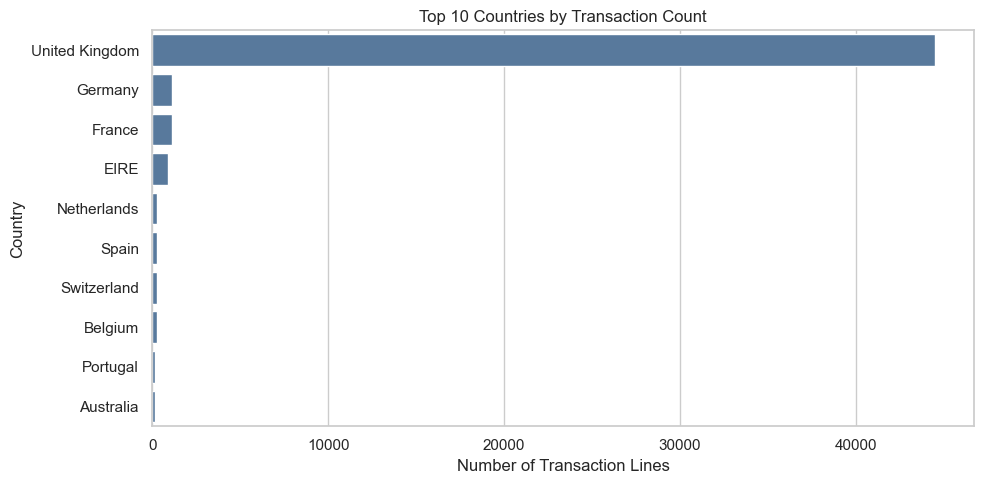

,Country,Transactions
0,United Kingdom,44481
1,Germany,1148
2,France,1115
3,EIRE,918
4,Netherlands,300
5,Spain,276
6,Switzerland,251
7,Belgium,246
8,Portugal,165
9,Australia,149


In [6]:
# Visualize transaction concentration by country.
# Country distribution is important because a dominant country can strongly influence patterns.
top_countries = retail["Country"].value_counts().head(10).reset_index()
top_countries.columns = ["Country", "Transactions"]

plt.figure(figsize=(10, 5))
sns.barplot(data=top_countries, x="Transactions", y="Country", color="#4C78A8")
plt.title("Top 10 Countries by Transaction Count")
plt.xlabel("Number of Transaction Lines")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

top_countries

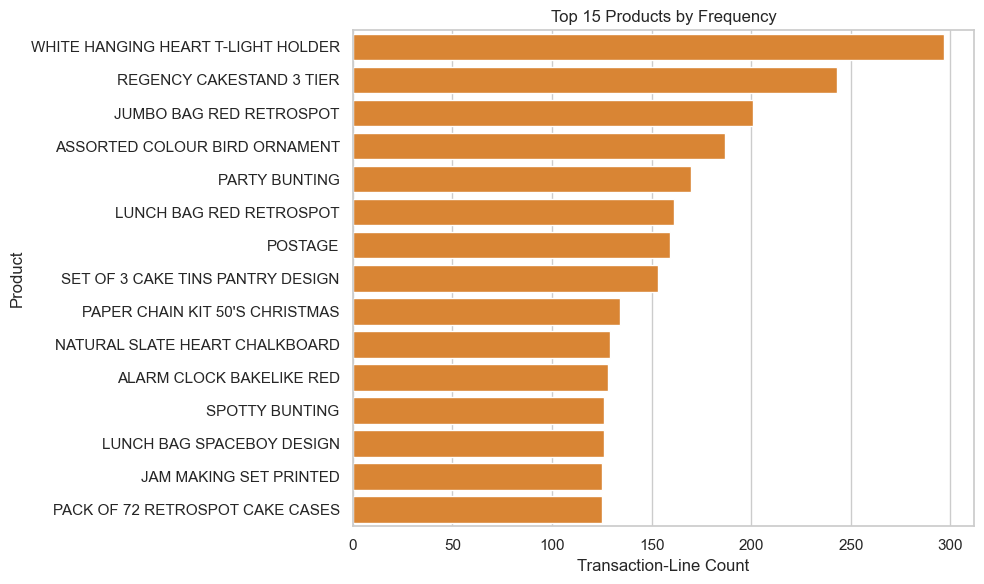

,Description,Count
0,WHITE HANGING HEART T-LIGHT HOLDER,297
1,REGENCY CAKESTAND 3 TIER,243
2,JUMBO BAG RED RETROSPOT,201
3,ASSORTED COLOUR BIRD ORNAMENT,187
4,PARTY BUNTING,170
5,LUNCH BAG RED RETROSPOT,161
6,POSTAGE,159
7,SET OF 3 CAKE TINS PANTRY DESIGN,153
8,PAPER CHAIN KIT 50'S CHRISTMAS,134
9,NATURAL SLATE HEART CHALKBOARD,129


In [7]:
# Identify frequently purchased products.
# Frequent products are useful for inventory planning and association rule mining.
top_products = retail["Description"].value_counts().head(15).reset_index()
top_products.columns = ["Description", "Count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x="Count", y="Description", color="#F58518")
plt.title("Top 15 Products by Frequency")
plt.xlabel("Transaction-Line Count")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

top_products

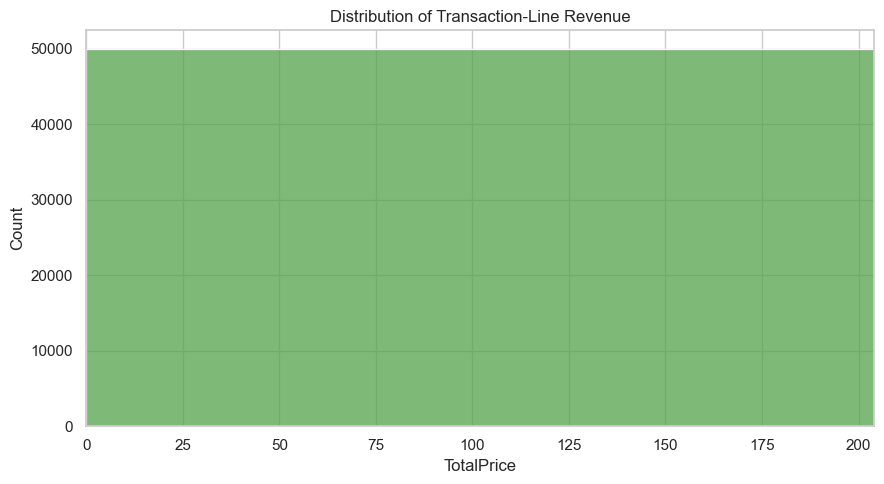

,count,mean,std,min,25%,50%,75%,max
Quantity,"50,000.0000",12.6262,42.9546,1.0000,2.0000,6.0000,12.0000,"4,800.0000"
UnitPrice,"50,000.0000",3.1367,16.6387,0.0010,1.2500,1.9500,3.7500,"2,500.0000"
TotalPrice,"50,000.0000",22.6451,187.0818,0.0010,4.9500,12.4800,19.8000,"38,970.0000"


In [8]:
# Examine revenue distribution.
# The 99th percentile limit keeps the plot readable while still showing the main distribution.
plt.figure(figsize=(9, 5))
sns.histplot(retail["TotalPrice"], bins=50, color="#54A24B")
plt.xlim(0, retail["TotalPrice"].quantile(0.99))
plt.title("Distribution of Transaction-Line Revenue")
plt.xlabel("TotalPrice")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

retail[["Quantity", "UnitPrice", "TotalPrice"]].describe().T

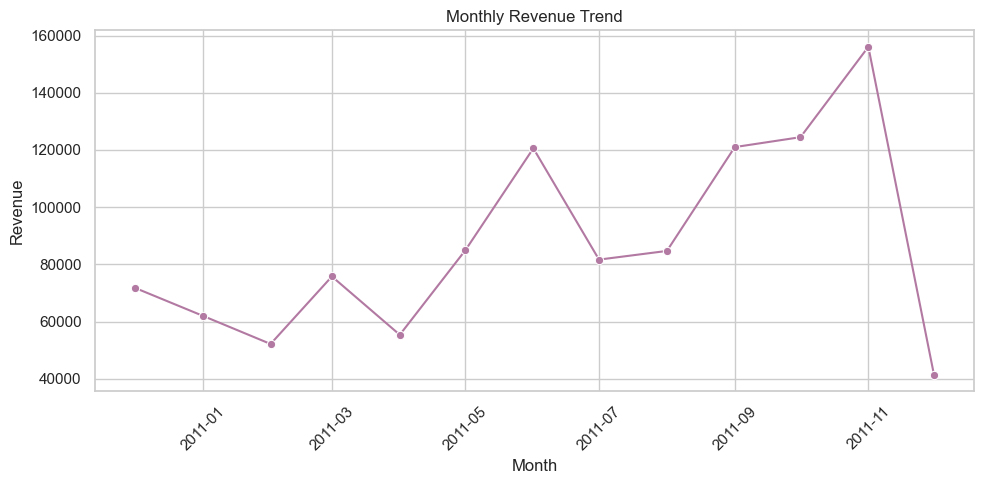

,InvoiceMonth,TotalPrice
0,2010-12-01,"71,834.9700"
1,2011-01-01,"62,069.6400"
2,2011-02-01,"52,215.9300"
3,2011-03-01,"75,805.5400"
4,2011-04-01,"55,421.9810"
5,2011-05-01,"85,016.3300"
6,2011-06-01,"120,584.1200"
7,2011-07-01,"81,694.3700"
8,2011-08-01,"84,725.7000"
9,2011-09-01,"121,010.6700"


In [9]:
# Analyze monthly revenue trends.
# Time-based trends help reveal seasonality and changes in demand.
monthly_sales = retail.groupby("InvoiceMonth", as_index=False)["TotalPrice"].sum()
monthly_sales["InvoiceMonth"] = pd.to_datetime(monthly_sales["InvoiceMonth"].astype(str))

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x="InvoiceMonth", y="TotalPrice", marker="o", color="#B279A2")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_sales

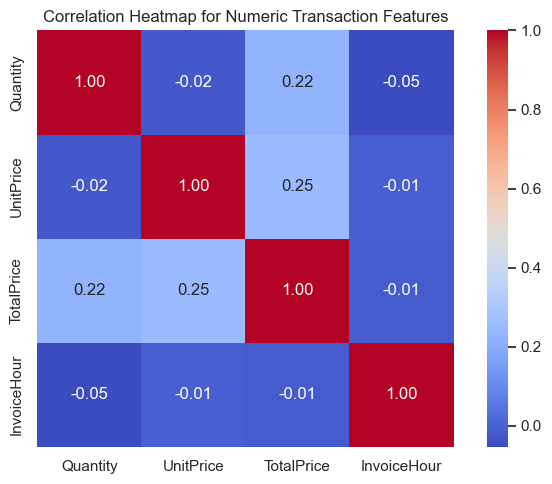

,Quantity,UnitPrice,TotalPrice,InvoiceHour
Quantity,1.0000,-0.0237,0.2246,-0.0526
UnitPrice,-0.0237,1.0000,0.2510,-0.0061
TotalPrice,0.2246,0.2510,1.0000,-0.0136
InvoiceHour,-0.0526,-0.0061,-0.0136,1.0000


In [10]:
# Correlation analysis among numeric variables.
# This helps identify variables that may be useful predictors in later modeling.
numeric_cols = ["Quantity", "UnitPrice", "TotalPrice", "InvoiceHour"]
corr = retail[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap for Numeric Transaction Features")
plt.tight_layout()
plt.show()

corr

### EDA Interpretation

The exploratory analysis shows that sales activity is concentrated in the United Kingdom and that a small group of products appears repeatedly across transactions. Revenue is right-skewed, meaning most purchases are small while a smaller number of invoices generate much larger sales. This pattern supports using a log-transformed revenue target for regression and also motivates high-value invoice classification.

## Deliverable 2: Regression Modeling

The regression task predicts invoice revenue using invoice-level features. Invoice-level modeling is appropriate because revenue is naturally measured per completed invoice, not per individual transaction line. The target variable is transformed using `log1p` to reduce skewness and improve model stability.

In [11]:
# Feature engineering for regression.
# Calendar features are extracted because buying behavior can vary by month, weekday, and hour.
regression_df = invoice.copy()
regression_df["invoice_month_number"] = regression_df["InvoiceDate"].dt.month
regression_df["invoice_dayofweek"] = regression_df["InvoiceDate"].dt.dayofweek
regression_df["log_invoice_total"] = np.log1p(regression_df["invoice_total"])

regression_features = [
    "total_quantity",
    "unique_items",
    "line_items",
    "avg_unit_price",
    "InvoiceHour",
    "invoice_month_number",
    "invoice_dayofweek",
    "Country",
]

X_reg = regression_df[regression_features]
y_reg = regression_df["log_invoice_total"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Regression training rows:", X_train_reg.shape[0])
print("Regression testing rows:", X_test_reg.shape[0])
X_reg.head()

Regression training rows: 14825
Regression testing rows: 3707


,total_quantity,unique_items,line_items,avg_unit_price,InvoiceHour,invoice_month_number,invoice_dayofweek,Country
0,40,7,7,3.9100,8,12,2,United Kingdom
1,12,2,2,1.8500,8,12,2,United Kingdom
2,83,12,12,4.8533,8,12,2,United Kingdom
3,15,4,4,4.7750,8,12,2,United Kingdom
4,3,1,1,5.9500,8,12,2,United Kingdom


In [12]:
# Build preprocessing pipeline.
# Numeric variables are standardized for linear models, and country is one-hot encoded.
numeric_features = [
    "total_quantity",
    "unique_items",
    "line_items",
    "avg_unit_price",
    "InvoiceHour",
    "invoice_month_number",
    "invoice_dayofweek",
]
categorical_features = ["Country"]

preprocess_reg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

regression_models = {
    "Multiple Linear Regression": Pipeline([
        ("prep", preprocess_reg),
        ("model", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline([
        ("prep", preprocess_reg),
        ("model", Ridge(alpha=1.0)),
    ]),
    "Random Forest Regression": Pipeline([
        ("prep", preprocess_reg),
        ("model", RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)),
    ]),
}

def evaluate_regression_model(name, model):
    """Train a regression model and return test and cross-validation metrics."""
    model.fit(X_train_reg, y_train_reg)
    predictions = model.predict(X_test_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, predictions))
    cv_rmse = -cross_val_score(
        model,
        X_reg,
        y_reg,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    ).mean()
    return {
        "model": name,
        "test_mae": mean_absolute_error(y_test_reg, predictions),
        "test_mse": mean_squared_error(y_test_reg, predictions),
        "test_rmse": rmse,
        "test_r2": r2_score(y_test_reg, predictions),
        "cv_rmse": cv_rmse,
    }

regression_results = pd.DataFrame([
    evaluate_regression_model(name, model)
    for name, model in regression_models.items()
]).sort_values("test_rmse")

regression_results

,model,test_mae,test_mse,test_rmse,test_r2,cv_rmse
2,Random Forest Regression,0.1890,0.0718,0.2679,0.9345,0.2728
1,Ridge Regression,0.6335,0.7710,0.8781,0.2969,0.9067
0,Multiple Linear Regression,0.6334,0.7713,0.8783,0.2966,0.9071


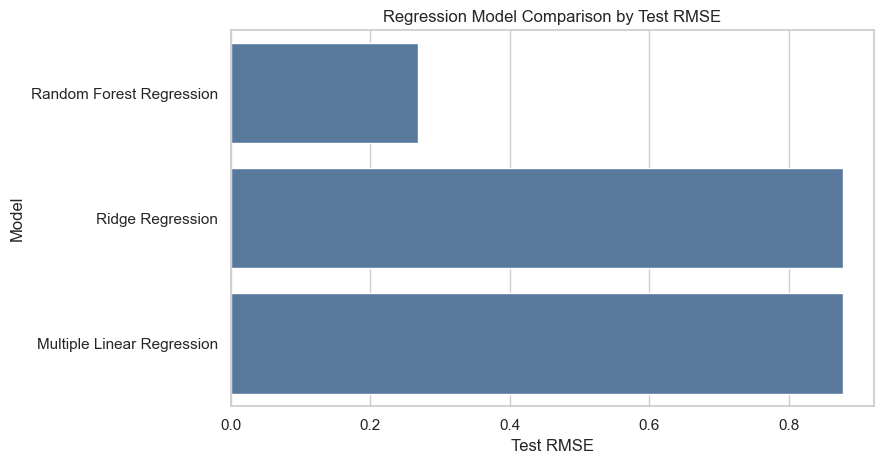

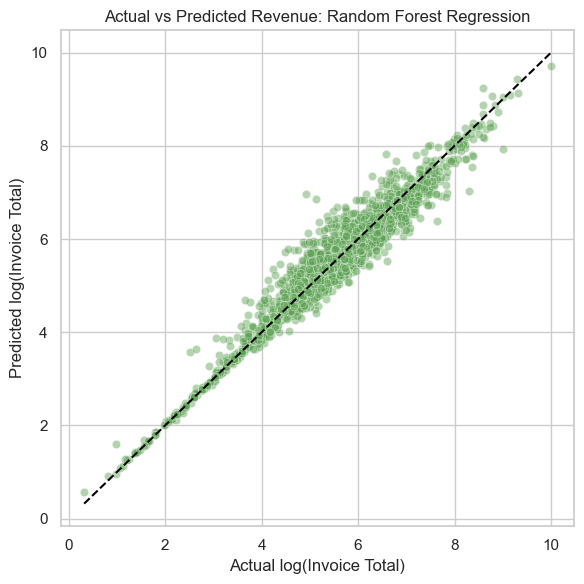

In [13]:
# Visualize model comparison using RMSE.
# Lower RMSE indicates better prediction accuracy on the log-transformed invoice total.
plt.figure(figsize=(9, 4.8))
sns.barplot(data=regression_results, x="test_rmse", y="model", color="#4C78A8")
plt.title("Regression Model Comparison by Test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

# Plot predicted vs actual values for the best regression model.
best_regression_name = regression_results.iloc[0]["model"]
best_regression_model = regression_models[best_regression_name]
best_regression_model.fit(X_train_reg, y_train_reg)
regression_predictions = best_regression_model.predict(X_test_reg)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_reg, y=regression_predictions, alpha=0.45, color="#59A14F")
min_val = min(y_test_reg.min(), regression_predictions.min())
max_val = max(y_test_reg.max(), regression_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--")
plt.title(f"Actual vs Predicted Revenue: {best_regression_name}")
plt.xlabel("Actual log(Invoice Total)")
plt.ylabel("Predicted log(Invoice Total)")
plt.tight_layout()
plt.show()

### Regression Interpretation

Multiple Linear Regression and Ridge Regression provide useful baselines, but they assume mostly linear relationships between predictors and revenue. Random Forest Regression performed better because invoice value is influenced by nonlinear combinations of quantity, number of unique products, line count, unit price, country, and purchase timing. Cross-validation is included to check whether the result is stable beyond a single train-test split.

## Deliverable 3: Classification

The classification task predicts whether an invoice is high value. The label is based on the top quartile of invoice totals, which creates a practical business target: identifying transactions that may deserve priority handling, retention attention, or targeted promotions.

In [14]:
# Prepare classification data.
# The high_value_invoice label was created from the upper quartile of invoice totals.
classification_df = invoice.copy()
classification_df["invoice_month_number"] = classification_df["InvoiceDate"].dt.month
classification_df["invoice_dayofweek"] = classification_df["InvoiceDate"].dt.dayofweek

X_cls = classification_df[regression_features]
y_cls = classification_df["high_value_invoice"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls,
)

print("Class distribution:")
print(y_cls.value_counts(normalize=True).rename("proportion"))

Class distribution:
high_value_invoice
0   0.7500
1   0.2500
Name: proportion, dtype: float64


In [15]:
# Reuse preprocessing for classification because the predictors have the same structure.
preprocess_cls = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

classification_models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocess_cls),
        ("model", LogisticRegression(max_iter=2000)),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess_cls),
        ("model", RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)),
    ]),
}

def evaluate_classifier(name, model):
    """Train a classifier and return accuracy, F1, and ROC-AUC metrics."""
    model.fit(X_train_cls, y_train_cls)
    predictions = model.predict(X_test_cls)
    probabilities = model.predict_proba(X_test_cls)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test_cls, predictions),
        "f1": f1_score(y_test_cls, predictions),
        "roc_auc": roc_auc_score(y_test_cls, probabilities),
    }

classification_results = pd.DataFrame([
    evaluate_classifier(name, model)
    for name, model in classification_models.items()
]).sort_values("roc_auc", ascending=False)

classification_results

,model,accuracy,f1,roc_auc
1,Random Forest,0.9150,0.8178,0.9676
0,Logistic Regression,0.8738,0.7097,0.9249


In [16]:
# Tune the Random Forest classifier.
# GridSearchCV tests several parameter combinations and selects the best one using ROC-AUC.
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [6, 10, None],
    "model__min_samples_leaf": [1, 3],
}

grid = GridSearchCV(
    classification_models["Random Forest"],
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
)

grid.fit(X_train_cls, y_train_cls)

best_classifier = grid.best_estimator_
tuned_predictions = best_classifier.predict(X_test_cls)
tuned_probabilities = best_classifier.predict_proba(X_test_cls)[:, 1]

tuned_result = pd.DataFrame([{
    "model": "Tuned Random Forest",
    "accuracy": accuracy_score(y_test_cls, tuned_predictions),
    "f1": f1_score(y_test_cls, tuned_predictions),
    "roc_auc": roc_auc_score(y_test_cls, tuned_probabilities),
    "best_params": grid.best_params_,
}])

tuned_result

,model,accuracy,f1,roc_auc,best_params
0,Tuned Random Forest,0.9177,0.8244,0.9681,"{'model__max_depth': None, 'model__min_samples..."


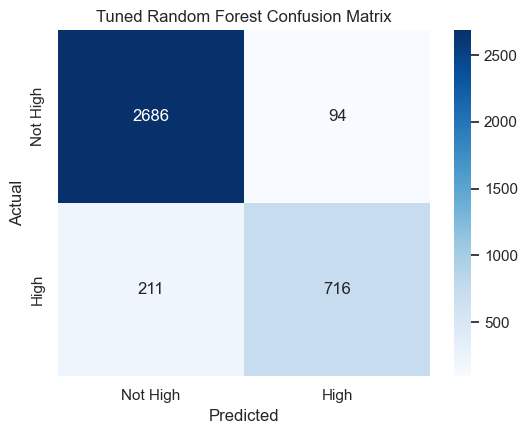

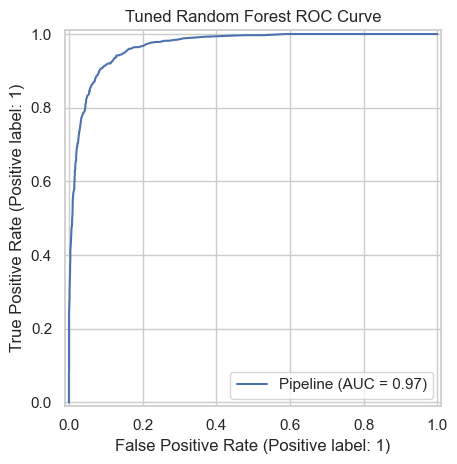

In [17]:
# Confusion matrix shows the types of classification errors.
cm = confusion_matrix(y_test_cls, tuned_predictions)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not High", "High"], yticklabels=["Not High", "High"])
plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curve evaluates the model across different probability thresholds.
RocCurveDisplay.from_estimator(best_classifier, X_test_cls, y_test_cls)
plt.title("Tuned Random Forest ROC Curve")
plt.tight_layout()
plt.show()

### Classification Interpretation

Logistic Regression is useful as a transparent baseline, while Random Forest captures nonlinear patterns and feature interactions. Hyperparameter tuning improves confidence that the model configuration was selected systematically. The confusion matrix helps identify false positives and false negatives, while the ROC curve shows how well the model separates high-value and non-high-value invoices across thresholds.

## Deliverable 3: Customer Clustering

Customer clustering uses RFM-style behavior: recency, frequency, monetary value, quantity purchased, product variety, and average order value. This converts many individual transactions into customer profiles that can support segmentation and marketing decisions.

In [18]:
# Prepare customer features for clustering.
# Clipping at the 99th percentile reduces the influence of extreme customers before scaling.
cluster_features = [
    "recency_days",
    "frequency",
    "total_quantity",
    "unique_items",
    "monetary",
    "avg_order_value",
]

customer_cluster_df = customer.copy()
cluster_input = customer_cluster_df[cluster_features].clip(
    upper=customer_cluster_df[cluster_features].quantile(0.99),
    axis=1,
)

scaler = StandardScaler()
scaled_customers = scaler.fit_transform(cluster_input)

# Four clusters give interpretable retail segments such as inactive, occasional, regular, and high-value groups.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_cluster_df["cluster"] = kmeans.fit_predict(scaled_customers)

cluster_score = silhouette_score(scaled_customers, customer_cluster_df["cluster"])
print(f"Customer clustering silhouette score: {cluster_score:.4f}")

cluster_summary = customer_cluster_df.groupby("cluster")[cluster_features].mean().round(2)
cluster_summary

Customer clustering silhouette score: 0.4034


,recency_days,frequency,total_quantity,unique_items,monetary,avg_order_value
cluster,,,,,,
0,49.1300,2.7700,513.5800,42.8300,859.7500,28.6400
1,18.2800,31.0500,"19,178.2600",223.9900,"33,749.7800","1,536.1000"
2,26.0500,9.8400,"2,272.6400",164.3900,"3,864.0800",20.8500
3,250.7500,1.4800,236.9800,22.4100,440.0600,43.1100


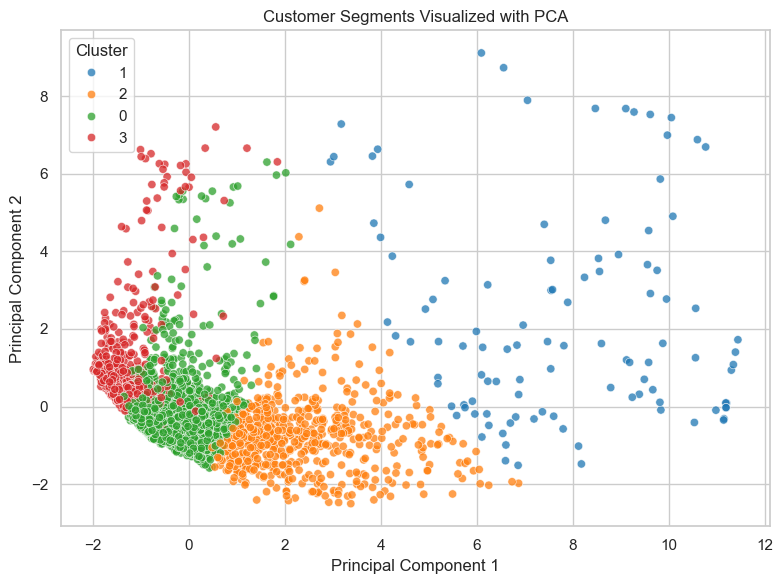

In [19]:
# PCA is used only for visualization; clustering is performed on the full standardized feature set.
pca = PCA(n_components=2, random_state=42)
customer_points = pca.fit_transform(scaled_customers)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=customer_points[:, 0],
    y=customer_points[:, 1],
    hue=customer_cluster_df["cluster"].astype(str),
    palette="tab10",
    alpha=0.75,
)
plt.title("Customer Segments Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### Clustering Interpretation

The clusters separate customers by purchasing intensity and recency. Customers with high monetary value, high frequency, and many unique items represent important retention targets. Customers with high recency and low frequency may require reactivation strategies. The silhouette score provides a quantitative check of cluster separation, while the PCA plot provides a visual summary of how the segments are positioned.

## Deliverable 3: Association Rule Mining

Association rule mining identifies products that frequently appear together in the same invoice. This is useful for recommendation systems, product bundling, store layout decisions, and targeted promotions. FP-Growth is used because it efficiently mines frequent itemsets without repeatedly scanning candidate combinations.

In [20]:
# Convert invoice-product records into basket format.
# Each transaction is a list of unique products purchased together on one invoice.
transactions = basket_source.groupby("InvoiceNo")["Description"].apply(lambda s: sorted(set(s))).tolist()

encoder = TransactionEncoder()
encoded_array = encoder.fit(transactions).transform(transactions)
basket_matrix = pd.DataFrame(encoded_array, columns=encoder.columns_)

print("Number of baskets:", len(transactions))
print("Number of encoded products:", basket_matrix.shape[1])
basket_matrix.head()

Number of baskets: 12820
Number of encoded products: 75


,6 RIBBONS RUSTIC CHARM,60 TEATIME FAIRY CAKE CASES,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,ASSORTED COLOUR BIRD ORNAMENT,BAKING SET 9 PIECE RETROSPOT,CHOCOLATE HOT WATER BOTTLE,CLOTHES PEGS RETROSPOT PACK 24,COOK WITH WINE METAL SIGN,DOORMAT KEEP CALM AND COME IN,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,GIN + TONIC DIET METAL SIGN,GREEN REGENCY TEACUP AND SAUCER,HAND OVER THE CHOCOLATE SIGN,HAND WARMER OWL DESIGN,HEART OF WICKER LARGE,HEART OF WICKER SMALL,HOME BUILDING BLOCK WORD,HOT WATER BOTTLE KEEP CALM,JAM MAKING SET PRINTED,JAM MAKING SET WITH JARS,JUMBO BAG BAROQUE BLACK WHITE,JUMBO BAG 50'S CHRISTMAS,JUMBO BAG ALPHABET,...,PLEASE ONE PERSON METAL SIGN,POPCORN HOLDER,RABBIT NIGHT LIGHT,RECIPE BOX PANTRY YELLOW DESIGN,RED HANGING HEART T-LIGHT HOLDER,RED RETROSPOT CHARLOTTE BAG,REGENCY CAKESTAND 3 TIER,RETROSPOT TEA SET CERAMIC 11 PC,REX CASH+CARRY JUMBO SHOPPER,ROSES REGENCY TEACUP AND SAUCER,SCOTTIE DOG HOT WATER BOTTLE,SET OF 3 CAKE TINS PANTRY DESIGN,SET OF 3 REGENCY CAKE TINS,SET OF 4 PANTRY JELLY MOULDS,SET OF 6 SPICE TINS PANTRY DESIGN,SET/20 RED RETROSPOT PAPER NAPKINS,SET/5 RED RETROSPOT LID GLASS BOWLS,SMALL WHITE HEART OF WICKER,SPOTTY BUNTING,VICTORIAN GLASS HANGING T-LIGHT,VINTAGE SNAP CARDS,WHITE HANGING HEART T-LIGHT HOLDER,WOOD BLACK BOARD ANT WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True


In [21]:
# Mine frequent itemsets and association rules.
# The support threshold is kept moderate so meaningful repeated patterns are retained.
frequent_itemsets = fpgrowth(basket_matrix, min_support=0.025, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.35)
rules = rules.sort_values(["lift", "confidence"], ascending=False)

print("Frequent itemsets found:", len(frequent_itemsets))
print("Association rules found:", len(rules))
frequent_itemsets.head(10)

Frequent itemsets found: 112
Association rules found: 59


,support,itemsets,length
0,0.1470,(WHITE HANGING HEART T-LIGHT HOLDER),1
26,0.1129,(JUMBO BAG RED RETROSPOT),1
46,0.1100,(REGENCY CAKESTAND 3 TIER),1
1,0.1014,(ASSORTED COLOUR BIRD ORNAMENT),1
52,0.1006,(PARTY BUNTING),1
8,0.0874,(LUNCH BAG RED RETROSPOT),1
53,0.0785,(SET OF 3 CAKE TINS PANTRY DESIGN),1
38,0.0777,(LUNCH BAG BLACK SKULL.),1
4,0.0737,(PAPER CHAIN KIT 50'S CHRISTMAS),1
22,0.0732,(NATURAL SLATE HEART CHALKBOARD),1


In [22]:
# Display top association rules with readable antecedent and consequent labels.
top_rules = rules.head(10).copy()
top_rules["antecedents"] = top_rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
top_rules["consequents"] = top_rules["consequents"].apply(lambda x: ", ".join(sorted(x)))

top_rules[["antecedents", "consequents", "support", "confidence", "lift"]]

,antecedents,consequents,support,confidence,lift
3,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.0371,0.7778,14.7067
4,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0371,0.7021,14.7067
7,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.0357,0.7305,12.6207
8,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.0357,0.6173,12.6207
12,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.0354,0.6580,11.1282
11,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.0354,0.5989,11.1282
9,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.0357,0.5842,8.7696
10,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.0357,0.5363,8.7696
16,PAPER CHAIN KIT VINTAGE CHRISTMAS,PAPER CHAIN KIT 50'S CHRISTMAS,0.0341,0.6455,8.7569
15,PAPER CHAIN KIT 50'S CHRISTMAS,PAPER CHAIN KIT VINTAGE CHRISTMAS,0.0341,0.4624,8.7569


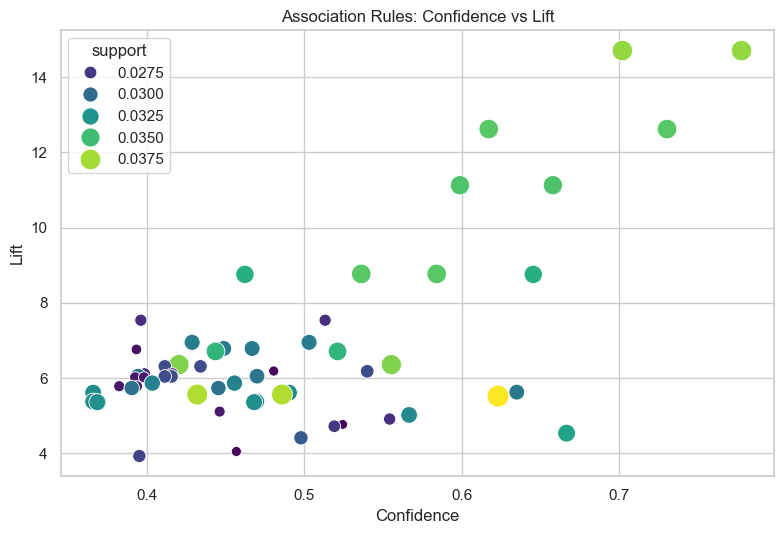

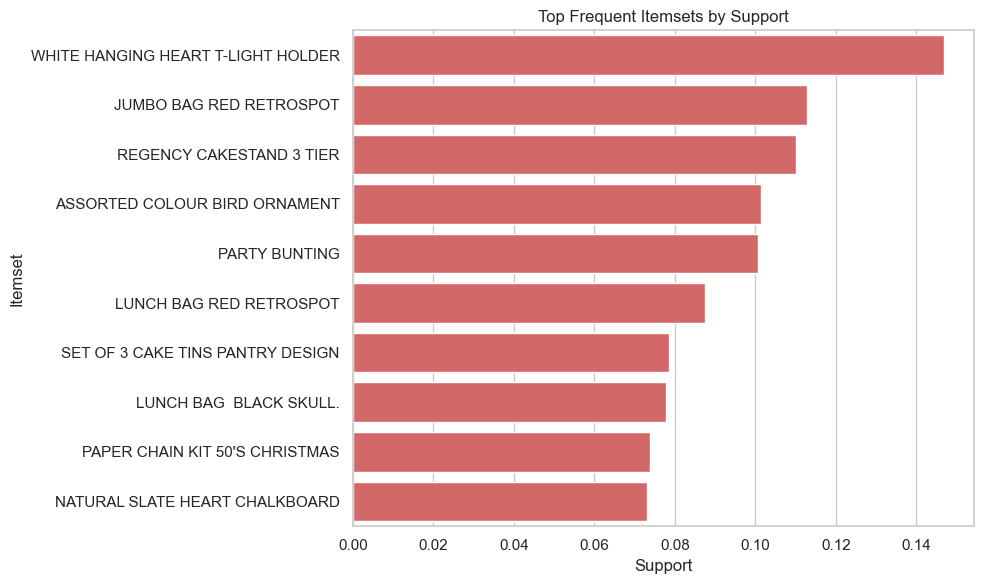

In [23]:
# Visualize strongest association rules.
# Higher lift indicates stronger association beyond random co-occurrence.
plt.figure(figsize=(8, 5.5))
sns.scatterplot(
    data=rules,
    x="confidence",
    y="lift",
    size="support",
    hue="support",
    palette="viridis",
    sizes=(50, 250),
)
plt.title("Association Rules: Confidence vs Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.tight_layout()
plt.show()

# Visualize top frequent itemsets for communication.
plot_itemsets = frequent_itemsets.head(10).copy()
plot_itemsets["itemset_label"] = plot_itemsets["itemsets"].apply(lambda x: ", ".join(sorted(x)))
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_itemsets, x="support", y="itemset_label", color="#E45756")
plt.title("Top Frequent Itemsets by Support")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.tight_layout()
plt.show()

### Association Rule Interpretation

The strongest rules often involve related product families, such as matching designs or complementary household items. Support shows how common the combination is, confidence shows how often the consequent appears when the antecedent appears, and lift shows whether the relationship is stronger than random chance. These rules should be interpreted as behavioral associations, not proof that one product causes another purchase.

## Final Comparison and Recommendations

The project demonstrates how different data mining methods answer different business questions from the same retail dataset.

- **EDA** revealed country concentration, frequent products, skewed revenue, and seasonal patterns.
- **Regression** showed that invoice-level features can estimate revenue, with Random Forest Regression performing best because of nonlinear purchasing behavior.
- **Classification** showed that high-value invoices can be identified with strong accuracy and ROC-AUC, supporting prioritization and targeted business actions.
- **Clustering** created customer segments based on behavioral patterns, supporting retention, reactivation, and customer relationship strategies.
- **Association rules** identified products that commonly appear together, supporting cross-selling and product bundling.

Recommended business actions include monitoring UK sales concentration, targeting high-value and high-frequency customer segments, using association rules for bundled recommendations, and reviewing model performance over time as customer behavior changes.

Ethically, customer identifiers should be protected, models should be used to support decisions rather than replace judgment, and results should be monitored to avoid unfair exclusion of certain customer groups or countries.